# Analiza podatkov iz knjige Orgle Slovenije

## Pridobitev in zapis podatkov

**OPOMBA:** Podrobnejši opis strukture podatkov v CSV datoteki se nahaja v datoteki [`README.md`](README.md#struktura-podatkov).

In [7]:
import pandas as pd

from orodja.pridobivanje_podatkov import pridobi_orglarje
from orodja.zapisovanje_podatkov import zapisi_orglarje_v_csv

orglarji = pridobi_orglarje()
zapisi_orglarje_v_csv(orglarji)

org = pd.read_csv('podatki/orglarji.csv')

## Analiza

### Kako se je spreminjalo število aktivnih orglarjev na slovenskem območju

1. Aktivnost orglarjev sem gledal po desetletnih obdobjih, torej sem za določeno desetletje vzel le tistega orglarja, ki je bil vsaj 1 leto aktiven v njem.
2. Glede na podatke pod slovenska območja štejem:
    - LJ: Ljubljana z okolico in Gorenjska,
    - MB: Maribor in Podravje,
    - CE: Savinjska,
    - NM: Dolenjska,
    - GO: Goriška,
    - KO: Koroška.
3. Orglarja Georgius de Venetia iz leta 826 sem izpustil zaradi preglednosti grafa.
4. Število orglarjev na slovenskem območju sem na grafu primerjal s številom vseh orglarjev v knjigi.

**POMEMBNO:** Ta analiza naj nam ne bo najbolj verodostojna, saj orglarji najverjetneje niso delali samo v omenjenih območjih skozi celotno obdobje delovanja.

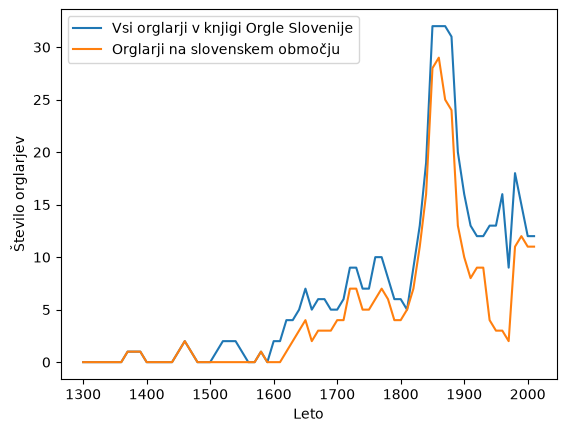

In [8]:
import matplotlib.pyplot as plt

from orodja.filtriranje_podatkov import *

# Sestavimo seznam orglarjev, ki so bili aktivni v določenem desetletnem obdobju
ZACETEK, KONEC = 1300, 2020
org_v_deset = pridobi_orglarje_po_desetletjih(org, ZACETEK, KONEC)

# Pridobimo orglarje, ki so delali na slovenskem območju
SLOVENSKA_OBMOCJA = ["LJ", "MB", "CE", "NM", "GO", "KO"]
slo_org_v_deset = [pridobi_orglarje_v_obmocjih(o, SLOVENSKA_OBMOCJA) for o in org_v_deset]

# Preštejemo število orglarjev v desetletnih obdobjih
st_orglarjev = list(map(len, org_v_deset))
st_slo_orglarjev = list(map(len, slo_org_v_deset))

# Število orglarjev na slovenskem območju primerjamo na grafu s številom vseh orglarjev v knjigi
desetletja = range(ZACETEK, KONEC, 10)
plt.plot(desetletja, st_orglarjev, label="Vsi orglarji v knjigi Orgle Slovenije")
plt.plot(desetletja, st_slo_orglarjev, label="Orglarji na slovenskem območju")

# Nastavimo prikaz grafa
plt.xlabel("Leto")
plt.ylabel("Število orglarjev")
plt.legend(loc='upper left');

Iz grafa lahko sklepamo (ugibamo) sledeče:
- Število orglarjev na slovenskih in tujih območjih se je večinoma spreminjalo v istem toku.
- Največ orglarjev je delovalo v drugi polovici 19. stoletja.
- V času prve in druge svetovne vojne se je število orglarjev izrazito zmanjšalo.
- V času vojen je na slovenskem območju v primerjavi s sosednjimi območji orglarska obrt bolj zakrnela.

### Kako se je spreminjalo število aktivnih orglarjev po območjih

1. Aktivnost orglarjev sem ponovno gledal po desetletnih obdobjih (prav tako nisem upošteval orglarja iz leta 826).
2. Zaradi preglednosti sem izbral le 4 območja z največ orglarji.

**POMEMBNO:** Ta analiza naj nam ne bo najbolj verodostojna, saj orglarji najverjetneje niso delali samo v omenjenih območjih skozi celotno obdobje delovanja.

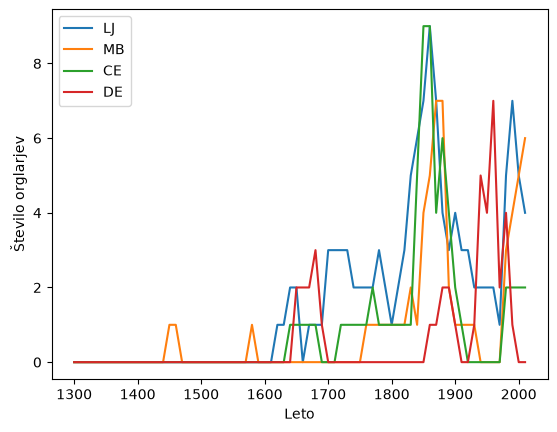

In [9]:
VSA_OBMOCJA = [
    "AT", "CE", "CZ", "DN", "NM", "GO", "GR",
    "HR", "IT", "KO", "LJ", "HU", "DE", "NL",
    "MB", "SW", "CH", "TS", "GB"
]

# Sestavimo seznam orglarjev, ki so bili aktivni v določenem območju
org_po_obm = [
    (obmocje, pridobi_orglarje_v_obmocjih(org, [obmocje])) 
    for obmocje in VSA_OBMOCJA
]

# Območja sortiramo glede na število orglarjev
org_po_obm.sort(reverse=True, key=lambda x: len(x[1]))

# Vzamemo 4 območja z največ orglarji in po desetlenih obdobjih vse zapišemo v en graf
for org_obm in org_po_obm[:4]:
    org_v_deset = pridobi_orglarje_po_desetletjih(org_obm[1], ZACETEK, KONEC)
    st_orglarjev = list(map(len, org_v_deset))
    
    plt.plot(desetletja, st_orglarjev, label=org_obm[0])

# Nastavimo prikaz grafa
plt.xlabel("Leto")
plt.ylabel("Število orglarjev")
plt.legend(loc='upper left');

Največ orglarjev je delovalo v območjih:
1. LJ: Ljubljana z okolico in Gorenjska,
2. MB: Maribor in Podravje,
3. CE: Savinjska,
4. DE: Nemčija.

Iz grafa lahko sklepamo (ugibamo) sledeče:
- (Slovenska) območja LJ, MB in CE so se gibala v drugačnem toku kot DE.
- Ponovno lahko vidim zakrnitev orglarske obrti na Slovenskem v času vojen (oziroma po njih), medtem ko so nemške delavnice ravno takrat najbolj aktivne na slovenskem ozemlju.
- Ob koncu 20. stoletja je orglarska obrt na slovenskem območju ponovno zaživela.
- V 21. stoletju začnejo ponovno prevladovati orglarji na slovenskem območju.